# CLIP → SigLIP (TensorFlow/Keras): contrastive vision-language pretraining from scratch




## 1. Setup

In [ ]:
!pip install -q datasets transformers tensorflow --upgrade


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.9/572.9 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.4/340.4 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 51.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.0 which is incompatible.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.21.0 whi

In [ ]:
import os, math, time, json, random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
print("GPUs available:", gpus)
if not gpus:
    print("WARNING: no GPU detected. Runtime -> Change runtime type -> T4 GPU")


GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Config

Everything that controls model size, training length, and data lives here.
Tweak this cell only the rest of the notebook reads from `CFG`.

In [ ]:
CFG = {
    # data
    "img_size": 128,
    "max_text_len": 40,
    "batch_size": 128,
    "val_fraction": 0.05,

    # model
    "embed_dim": 256,
    "proj_dim": 256,
    "img_patch_size": 16,
    "img_depth": 6,
    "img_heads": 8,
    "txt_depth": 4,
    "txt_heads": 8,
    "dropout": 0.1,

    # training
    "num_epochs": 8,          # bump this up once the pipeline is verified to work
    "lr": 3e-4,
    "weight_decay": 0.05,
    "warmup_steps": 200,

    # misc
    "tokenizer_name": "distilbert-base-uncased",  # tokenizer only — no pretrained weights used
    "checkpoint_dir": "/content/checkpoints",
    "save_to_drive": False,   # set True + run the drive-mount cell to persist checkpoints
    "drive_checkpoint_dir": "/content/drive/MyDrive/clip_siglip_project_tf/checkpoints",
}

os.makedirs(CFG["checkpoint_dir"], exist_ok=True)
CFG


{'img_size': 128,
 'max_text_len': 40,
 'batch_size': 128,
 'val_fraction': 0.05,
 'embed_dim': 256,
 'proj_dim': 256,
 'img_patch_size': 16,
 'img_depth': 6,
 'img_heads': 8,
 'txt_depth': 4,
 'txt_heads': 8,
 'dropout': 0.1,
 'num_epochs': 8,
 'lr': 0.0003,
 'weight_decay': 0.05,
 'warmup_steps': 200,
 'tokenizer_name': 'distilbert-base-uncased',
 'checkpoint_dir': '/content/checkpoints',
 'save_to_drive': False,
 'drive_checkpoint_dir': '/content/drive/MyDrive/clip_siglip_project_tf/checkpoints'}

## 3. (Optional) Mount Google Drive

Run this if you want checkpoints and logs to survive a Colab disconnect.
Skip it if you're happy losing state when the runtime recycles.

In [ ]:
if CFG["save_to_drive"]:
    from google.colab import drive
    drive.mount('/content/drive')
    os.makedirs(CFG["drive_checkpoint_dir"], exist_ok=True)
    print("Drive mounted. Checkpoints will also be copied to:", CFG["drive_checkpoint_dir"])
else:
    print("Skipping Drive mount (CFG['save_to_drive'] is False).")


## 4. Dataset — Flickr8k

Flickr8k has 8,000 images, each with 5 captions small enough to train fast on a single
GPU, large enough to show real zero-shot retrieval behavior.

We pull it from the Hugging Face Hub. If the primary source is unavailable, a fallback
and manual-download instructions are included below.

In [ ]:
from datasets import load_dataset

def load_flickr8k():
    candidates = ["jxie/flickr8k", "atasoglu/flickr8k-dataset"]
    last_err = None
    for name in candidates:
        try:
            print(f"Trying dataset: {name}")
            ds = load_dataset(name)
            print(f"Loaded '{name}' successfully.")
            return ds, name
        except Exception as e:
            print(f"  failed: {e}")
            last_err = e
    raise RuntimeError(
        "Could not load Flickr8k from any known HF mirror. "
        "Manual fallback: download from Kaggle "
        "(https://www.kaggle.com/datasets/adityajn105/flickr8k), upload to Colab or Drive, "
        "then adapt the data-loading cells below to read from the local `Images/` folder and "
        "`captions.txt`."
    ) from last_err

raw_ds, ds_name = load_flickr8k()
print(raw_ds)


Trying dataset: jxie/flickr8k


README.md:   0%|          | 0.00/687 [00:00<?, ?B/s]

data/train-00000-of-00002-2f8f6bfa852eac(…): reconstructing file:   0%|          |  0.00B /  414MB            

data/train-00000-of-00002-2f8f6bfa852eac(…): downloading bytes:           |  0.00B            

data/train-00001-of-00002-2173151d8cd6c7(…): reconstructing file:   0%|          |  0.00B /  414MB            

...

data/test-00000-of-00001-42a2661d12c73e4(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/6000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Loaded 'jxie/flickr8k' successfully.
DatasetDict({
    train: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 6000
    })
    validation: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
})


In [ ]:
# Normalize into a lightweight index of (row_idx, caption) — NOT (image, caption).
# We deliberately never decode or store images here. Accessing a single row of an
# HF `datasets` object (`split[i]`) decodes just that row's image on demand; accessing
# a whole column (`split[img_col]`) decodes every image in the dataset at once. We
# avoid both by only touching text columns now, and decoding one image at a time,
# later, inside the tf.data generator.

split = raw_ds["train"] if "train" in raw_ds else list(raw_ds.values())[0]
cols = split.column_names
img_col = "image" if "image" in cols else ("img" if "img" in cols else cols[0])
cap_list_col = next((c for c in cols if c in ("captions", "caption_list")), None)
single_cap_col = next((c for c in cols if c == "caption"), None)
numbered_cap_cols = [c for c in cols if c.lower().startswith("caption_")]

def build_index_pairs(split):
    index_pairs = []
    if cap_list_col is not None:
        cap_col_values = split[cap_list_col]  # text-only column access, cheap
        for row_idx, caps in enumerate(cap_col_values):
            for c in caps:
                if c:
                    index_pairs.append((row_idx, c.strip()))
    elif numbered_cap_cols:
        cols_values = [split[c] for c in numbered_cap_cols]  # text-only, cheap
        for row_idx in range(len(split)):
            for col_vals in cols_values:
                c = col_vals[row_idx]
                if c:
                    index_pairs.append((row_idx, c.strip()))
    elif single_cap_col is not None:
        cap_col_values = split[single_cap_col]
        for row_idx, c in enumerate(cap_col_values):
            if c:
                index_pairs.append((row_idx, c.strip()))
    else:
        raise RuntimeError("Could not find a caption column in this dataset schema.")
    return index_pairs

index_pairs = build_index_pairs(split)
print("total (row_idx, caption) pairs:", len(index_pairs))
print("example caption:", index_pairs[0][1])
print("image column:", img_col)


total (row_idx, caption) pairs: 30000
example caption: A black dog is running after a white dog in the snow .
image column: image


In [ ]:
# Train / val split (by pair, simple random split — fine for this scale)
random.shuffle(index_pairs)
n_val = max(1, int(len(index_pairs) * CFG["val_fraction"]))
val_index_pairs = index_pairs[:n_val]
train_index_pairs = index_pairs[n_val:]
print(f"train pairs: {len(train_index_pairs)} | val pairs: {len(val_index_pairs)}")


train pairs: 28500 | val pairs: 1500


## 5. Tokenizer, image preprocessing, and the tf.data pipeline

**Why this looks different from a "normal" tf.data setup:** the first version of this
pipeline decoded every image into a Python list up front and then cached the whole
preprocessed dataset a second time in RAM two full copies of a ~28k-image dataset,
which is enough to OOM-kill a standard Colab runtime (12.7GB system RAM) partway through
the first epoch, with the kernel silently auto-restarting rather than raising a normal
Python error. The version below decodes one image at a time, on demand, and caches to
**local disk** instead of memory the first epoch is a bit slower while the cache is
written, every epoch after that is just as fast as an in-memory cache would have been.

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(CFG["tokenizer_name"])
PAD_ID = tokenizer.pad_token_id
VOCAB_SIZE = tokenizer.vocab_size
print("vocab size:", VOCAB_SIZE, "| pad id:", PAD_ID)

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)


def preprocess_image(pil_img, img_size, augment):
    img = pil_img.convert("RGB").resize((img_size, img_size))
    arr = np.asarray(img, dtype=np.float32) / 255.0
    if augment and random.random() < 0.5:
        arr = arr[:, ::-1, :]  # horizontal flip
    arr = (arr - IMAGENET_MEAN) / IMAGENET_STD
    return arr.astype(np.float32)  # (H, W, 3), channels-last


def make_generator(index_pairs, split, img_col, img_size, max_len, augment):
    """Decodes exactly one image per yielded example — nothing accumulates in memory
    beyond what tf.data's shuffle/prefetch buffers need."""
    def gen():
        for row_idx, caption in index_pairs:
            pil_img = split[int(row_idx)][img_col]  # decodes ONE image, on demand
            img = preprocess_image(pil_img, img_size, augment)
            tok = tokenizer(caption, padding="max_length", truncation=True,
                             max_length=max_len, return_tensors="np")
            input_ids = tok["input_ids"][0].astype(np.int32)
            yield img, input_ids, caption
    return gen


def build_dataset(index_pairs, cfg, augment, shuffle, cache_tag):
    gen = make_generator(index_pairs, split, img_col, cfg["img_size"], cfg["max_text_len"], augment)
    output_signature = (
        tf.TensorSpec(shape=(cfg["img_size"], cfg["img_size"], 3), dtype=tf.float32),
        tf.TensorSpec(shape=(cfg["max_text_len"],), dtype=tf.int32),
        tf.TensorSpec(shape=(), dtype=tf.string),
    )
    ds = tf.data.Dataset.from_generator(gen, output_signature=output_signature)

    # Cache to LOCAL DISK, not RAM. tf.data's default `.cache()` (no filename) holds
    # the entire preprocessed dataset in memory — that's what caused the crash. Disk
    # is far more forgiving and Colab's local disk is much larger than its RAM.
    # The cache filename bakes in img_size/max_text_len so changing CFG can't silently
    # read a stale, mismatched cache from a previous run.
    cache_path = f"/content/tfcache_{cache_tag}_{cfg['img_size']}_{cfg['max_text_len']}"
    ds = ds.cache(cache_path)

    if shuffle:
        # Keep the shuffle buffer modest — it's real memory too (buffer_size * one
        # image's footprint). 2000 is enough randomness at this dataset scale without
        # adding meaningfully to memory pressure.
        ds = ds.shuffle(buffer_size=min(len(index_pairs), 2000), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(cfg["batch_size"], drop_remainder=shuffle)
    ds = ds.prefetch(2)  # fixed, small prefetch — AUTOTUNE can ramp buffers unpredictably under memory pressure
    return ds


train_dataset = build_dataset(train_index_pairs, CFG, augment=True, shuffle=True, cache_tag="train")
val_dataset = build_dataset(val_index_pairs, CFG, augment=False, shuffle=False, cache_tag="val")

train_steps_per_epoch = len(train_index_pairs) // CFG["batch_size"]
val_steps = math.ceil(len(val_index_pairs) / CFG["batch_size"])
print(f"train steps/epoch: {train_steps_per_epoch} | val steps: {val_steps}")

# Sanity-check shapes on a small, UNCACHED preview built separately from train/val —
# pulling a partial batch out of the real (shuffled, cached) train_dataset here would
# force a partial read of its disk cache and immediately discard it (tf.data only
# considers a cache valid after a full pass), wasting the first epoch's work for
# nothing. This preview never touches train_dataset/val_dataset at all.
preview_pairs = train_index_pairs[: min(CFG["batch_size"], len(train_index_pairs))]
preview_gen = make_generator(preview_pairs, split, img_col, CFG["img_size"], CFG["max_text_len"], augment=False)
preview_signature = (
    tf.TensorSpec(shape=(CFG["img_size"], CFG["img_size"], 3), dtype=tf.float32),
    tf.TensorSpec(shape=(CFG["max_text_len"],), dtype=tf.int32),
    tf.TensorSpec(shape=(), dtype=tf.string),
)
preview_ds = tf.data.Dataset.from_generator(preview_gen, output_signature=preview_signature).batch(len(preview_pairs))
for imgs, ids, caps in preview_ds.take(1):
    print("image batch shape:", imgs.shape, "| token ids shape:", ids.shape)
    print("example caption:", caps[0].numpy().decode())


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

vocab size: 30522 | pad id: 0
train steps/epoch: 222 | val steps: 12
image batch shape: (128, 128, 128, 3) | token ids shape: (128, 40)
example caption: The boy swings next to the barn .


## 6. Model — ViT image encoder + Transformer text encoder

Both encoders are implemented from scratch (no pretrained backbones) so the replication
is faithful to what CLIP/SigLIP actually are: two independently-trained encoders pulled
into a shared space by a contrastive objective. Only the *tokenizer* is reused from
`transformers` that's just text splitting, not learned weights.

In [ ]:
class PatchEmbed(layers.Layer):
    def __init__(self, patch_size, embed_dim, **kw):
        super().__init__(**kw)
        self.proj = layers.Conv2D(embed_dim, kernel_size=patch_size, strides=patch_size, padding="valid")

    def call(self, x):
        x = self.proj(x)
        B = tf.shape(x)[0]
        x = tf.reshape(x, (B, -1, x.shape[-1]))
        return x


class TransformerBlock(layers.Layer):
    def __init__(self, dim, n_heads, mlp_ratio=4.0, dropout=0.1, **kw):
        super().__init__(**kw)
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn = layers.MultiHeadAttention(num_heads=n_heads, key_dim=dim // n_heads, dropout=dropout)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        hidden = int(dim * mlp_ratio)
        self.mlp = tf.keras.Sequential([
            layers.Dense(hidden, activation="gelu"),
            layers.Dropout(dropout),
            layers.Dense(dim),
            layers.Dropout(dropout),
        ])

    def call(self, x, attention_mask=None, training=None):
        h = self.norm1(x)
        attn_out = self.attn(h, h, h, attention_mask=attention_mask, training=training)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x), training=training)
        return x


class ViTImageEncoder(layers.Layer):
    """Vision Transformer (Dosovitskiy et al., 2020), trimmed down for this dataset scale."""
    def __init__(self, img_size, patch_size, embed_dim, depth, n_heads, dropout=0.1, **kw):
        super().__init__(**kw)
        self.patch_embed = PatchEmbed(patch_size, embed_dim)
        self.n_patches = (img_size // patch_size) ** 2
        self.embed_dim = embed_dim
        self.blocks = [TransformerBlock(embed_dim, n_heads, dropout=dropout) for _ in range(depth)]
        self.norm = layers.LayerNormalization(epsilon=1e-6)

    def build(self, input_shape):
        self.cls_token = self.add_weight(
            name="cls_token", shape=(1, 1, self.embed_dim),
            initializer=tf.keras.initializers.TruncatedNormal(stddev=0.02))
        self.pos_embed = self.add_weight(
            name="pos_embed", shape=(1, self.n_patches + 1, self.embed_dim),
            initializer=tf.keras.initializers.TruncatedNormal(stddev=0.02))
        super().build(input_shape)

    def call(self, x, training=None):
        B = tf.shape(x)[0]
        x = self.patch_embed(x)
        cls = tf.tile(self.cls_token, [B, 1, 1])
        x = tf.concat([cls, x], axis=1)
        x = x + self.pos_embed
        for blk in self.blocks:
            x = blk(x, training=training)
        x = self.norm(x)
        return x[:, 0]


class TextTransformerEncoder(layers.Layer):
    """Small Transformer encoder over token ids, mean-pooled over non-pad tokens."""
    def __init__(self, vocab_size, max_len, embed_dim, depth, n_heads, dropout=0.1, pad_token_id=0, **kw):
        super().__init__(**kw)
        self.pad_token_id = pad_token_id
        self.token_embed = layers.Embedding(vocab_size, embed_dim)
        self.max_len = max_len
        self.embed_dim = embed_dim
        self.blocks = [TransformerBlock(embed_dim, n_heads, dropout=dropout) for _ in range(depth)]
        self.norm = layers.LayerNormalization(epsilon=1e-6)

    def build(self, input_shape):
        self.pos_embed = self.add_weight(
            name="pos_embed_txt", shape=(1, self.max_len, self.embed_dim),
            initializer=tf.keras.initializers.TruncatedNormal(stddev=0.02))
        super().build(input_shape)

    def call(self, input_ids, training=None):
        L = tf.shape(input_ids)[1]
        pad_mask = tf.not_equal(input_ids, self.pad_token_id)  # (B, L) True=real token
        attn_mask = tf.cast(pad_mask[:, tf.newaxis, :], tf.float32)
        attn_mask = tf.tile(attn_mask, [1, L, 1])  # (B, L, L)

        x = self.token_embed(input_ids) + self.pos_embed[:, :L]
        for blk in self.blocks:
            x = blk(x, attention_mask=attn_mask, training=training)
        x = self.norm(x)
        mask_f = tf.cast(pad_mask, tf.float32)[:, :, tf.newaxis]
        pooled = tf.reduce_sum(x * mask_f, axis=1) / tf.maximum(tf.reduce_sum(mask_f, axis=1), 1e-6)
        return pooled


class ProjectionHead(layers.Layer):
    """Maps an encoder's pooled output into the shared, L2-normalized embedding space."""
    def __init__(self, proj_dim, dropout=0.1, **kw):
        super().__init__(**kw)
        self.net = tf.keras.Sequential([
            layers.Dense(proj_dim, activation="gelu"),
            layers.Dropout(dropout),
            layers.Dense(proj_dim),
        ])

    def call(self, x, training=None):
        x = self.net(x, training=training)
        return tf.math.l2_normalize(x, axis=-1)


class DualEncoderModel(tf.keras.Model):
    """The shared architecture behind both CLIP and SigLIP — they differ only in the loss."""
    def __init__(self, cfg, vocab_size, pad_token_id, **kw):
        super().__init__(**kw)
        self.image_encoder = ViTImageEncoder(
            cfg["img_size"], cfg["img_patch_size"], cfg["embed_dim"],
            cfg["img_depth"], cfg["img_heads"], cfg["dropout"])
        self.text_encoder = TextTransformerEncoder(
            vocab_size, cfg["max_text_len"], cfg["embed_dim"],
            cfg["txt_depth"], cfg["txt_heads"], cfg["dropout"], pad_token_id)
        self.image_proj = ProjectionHead(cfg["proj_dim"], cfg["dropout"])
        self.text_proj = ProjectionHead(cfg["proj_dim"], cfg["dropout"])
        # learnable temperature (both CLIP and SigLIP); learnable bias (SigLIP only, unused by CLIP)
        self.logit_scale = tf.Variable(math.log(1 / 0.07), trainable=True, dtype=tf.float32, name="logit_scale")
        self.logit_bias = tf.Variable(0.0, trainable=True, dtype=tf.float32, name="logit_bias")

    def encode_image(self, images, training=None):
        return self.image_proj(self.image_encoder(images, training=training), training=training)

    def encode_text(self, input_ids, training=None):
        return self.text_proj(self.text_encoder(input_ids, training=training), training=training)

    def call(self, inputs, training=None):
        images, input_ids = inputs
        return self.encode_image(images, training=training), self.encode_text(input_ids, training=training)


def count_params(model):
    return sum(tf.size(v).numpy() for v in model.trainable_variables) / 1e6

_test_model = DualEncoderModel(CFG, VOCAB_SIZE, PAD_ID)
_ = _test_model((tf.zeros((2, CFG["img_size"], CFG["img_size"], 3)), tf.zeros((2, CFG["max_text_len"]), dtype=tf.int32)))
print(f"model params: {count_params(_test_model):.2f}M")
del _test_model


model params: 16.20M


## 7. Losses — CLIP (softmax InfoNCE) vs SigLIP (sigmoid)

**CLIP loss**: treats retrieval as an N-way classification problem over the batch for
each image, the matching caption is the "correct class" among all captions in the batch,
and vice versa. Needs a reasonably large batch to have enough negatives.

**SigLIP loss**: treats every image-caption pair independently as a binary
match/no-match decision (sigmoid, not softmax). This removes the need for a global
normalization over the batch, so it's more stable at small batch sizes relevant for us
since Colab GPU memory caps how large `batch_size` can realistically get.

In [ ]:
def clip_loss(image_embeds, text_embeds, logit_scale):
    scale = tf.exp(logit_scale)
    logits = scale * tf.matmul(image_embeds, text_embeds, transpose_b=True)
    n = tf.shape(logits)[0]
    labels = tf.range(n)
    loss_i = tf.reduce_mean(tf.nn.sparse_softmax_cross_entropy_with_logits(labels=labels, logits=logits))
    loss_t = tf.reduce_mean(tf.nn.sparse_softmax_cross_entropy_with_logits(labels=labels, logits=tf.transpose(logits)))
    return (loss_i + loss_t) / 2


def siglip_loss(image_embeds, text_embeds, logit_scale, logit_bias):
    n = tf.shape(image_embeds)[0]
    scale = tf.exp(logit_scale)
    logits = scale * tf.matmul(image_embeds, text_embeds, transpose_b=True) + logit_bias
    labels = 2.0 * tf.eye(n) - 1.0  # +1 diagonal (match), -1 off-diagonal
    loss = -tf.reduce_sum(tf.math.log_sigmoid(labels * logits)) / tf.cast(n, tf.float32)
    return loss


## 8. Training loop

In [ ]:
class WarmupCosineSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr, warmup_steps, total_steps):
        super().__init__()
        self.base_lr = base_lr
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup = tf.cast(self.warmup_steps, tf.float32)
        total = tf.cast(self.total_steps, tf.float32)
        warmup_lr = self.base_lr * (step / tf.maximum(warmup, 1.0))
        progress = (step - warmup) / tf.maximum(total - warmup, 1.0)
        cosine_lr = self.base_lr * 0.5 * (1.0 + tf.cos(math.pi * tf.clip_by_value(progress, 0.0, 1.0)))
        return tf.where(step < warmup, warmup_lr, cosine_lr)


def make_train_step(model, optimizer, loss_name):
    @tf.function
    def train_step(images, input_ids):
        with tf.GradientTape() as tape:
            img_e, txt_e = model((images, input_ids), training=True)
            if loss_name == "clip":
                loss = clip_loss(img_e, txt_e, model.logit_scale)
            else:
                loss = siglip_loss(img_e, txt_e, model.logit_scale, model.logit_bias)
        grads = tape.gradient(loss, model.trainable_variables)
        grads, _ = tf.clip_by_global_norm(grads, 1.0)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        return loss
    return train_step


def make_eval_step(model, loss_name):
    @tf.function
    def eval_step(images, input_ids):
        img_e, txt_e = model((images, input_ids), training=False)
        if loss_name == "clip":
            loss = clip_loss(img_e, txt_e, model.logit_scale)
        else:
            loss = siglip_loss(img_e, txt_e, model.logit_scale, model.logit_bias)
        return loss
    return eval_step


def evaluate_loss(eval_step, dataset):
    total, n_batches = 0.0, 0
    for images, input_ids, _ in dataset:
        total += eval_step(images, input_ids).numpy()
        n_batches += 1
    return total / max(1, n_batches)


def train_model(loss_name, cfg, tag):
    """loss_name: 'clip' or 'siglip'. tag: used for checkpoint filenames/logging."""
    assert loss_name in ("clip", "siglip")
    model = DualEncoderModel(cfg, VOCAB_SIZE, PAD_ID)
    total_steps = train_steps_per_epoch * cfg["num_epochs"]
    lr_schedule = WarmupCosineSchedule(cfg["lr"], cfg["warmup_steps"], total_steps)
    optimizer = tf.keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=cfg["weight_decay"])

    train_step = make_train_step(model, optimizer, loss_name)
    eval_step = make_eval_step(model, loss_name)

    history = {"train_loss": [], "val_loss": [], "step": []}
    step = 0
    t0 = time.time()

    for epoch in range(cfg["num_epochs"]):
        running, n_batches = 0.0, 0
        for images, input_ids, _ in train_dataset:
            loss = train_step(images, input_ids)
            running += loss.numpy()
            n_batches += 1
            step += 1
            if step % 50 == 0:
                cur_lr = lr_schedule(tf.cast(step, tf.float32)).numpy()
                print(f"[{tag}] epoch {epoch+1}/{cfg['num_epochs']} step {step}/{total_steps} "
                      f"loss {loss.numpy():.4f} lr {cur_lr:.2e} elapsed {time.time()-t0:.0f}s")

        train_epoch_loss = running / max(1, n_batches)
        val_epoch_loss = evaluate_loss(eval_step, val_dataset)
        history["train_loss"].append(train_epoch_loss)
        history["val_loss"].append(val_epoch_loss)
        history["step"].append(step)
        print(f"== [{tag}] epoch {epoch+1} done | train {train_epoch_loss:.4f} | val {val_epoch_loss:.4f} ==")

        ckpt_path = os.path.join(cfg["checkpoint_dir"], f"{tag}_epoch{epoch+1}.weights.h5")
        model.save_weights(ckpt_path)
        if cfg["save_to_drive"]:
            drive_path = os.path.join(cfg["drive_checkpoint_dir"], f"{tag}_epoch{epoch+1}.weights.h5")
            model.save_weights(drive_path)

    return model, history


## 9. Train CLIP

In [ ]:
clip_model, clip_history = train_model("clip", CFG, tag="clip")


[clip] epoch 1/8 step 50/1776 loss 4.8637 lr 7.50e-05 elapsed 107s
[clip] epoch 1/8 step 100/1776 loss 4.6166 lr 1.50e-04 elapsed 161s
[clip] epoch 1/8 step 150/1776 loss 4.6423 lr 2.25e-04 elapsed 214s
[clip] epoch 1/8 step 200/1776 loss 4.3275 lr 3.00e-04 elapsed 268s
== [clip] epoch 1 done | train 4.6586 | val 4.4127 ==
[clip] epoch 2/8 step 250/1776 loss 4.4361 lr 2.99e-04 elapsed 307s
[clip] epoch 2/8 step 300/1776 loss 4.4158 lr 2.97e-04 elapsed 327s
[clip] epoch 2/8 step 350/1776 loss 4.5304 lr 2.93e-04 elapsed 347s
[clip] epoch 2/8 step 400/1776 loss 4.0748 lr 2.88e-04 elapsed 368s
== [clip] epoch 2 done | train 4.2718 | val 4.2349 ==
[clip] epoch 3/8 step 450/1776 loss 4.1193 lr 2.82e-04 elapsed 392s
[clip] epoch 3/8 step 500/1776 loss 4.1087 lr 2.74e-04 elapsed 413s
[clip] epoch 3/8 step 550/1776 loss 3.8196 lr 2.65e-04 elapsed 433s
[clip] epoch 3/8 step 600/1776 loss 3.9306 lr 2.55e-04 elapsed 453s
[clip] epoch 3/8 step 650/1776 loss 3.8814 lr 2.44e-04 elapsed 473s
== [clip]

## 10. Zero-shot retrieval evaluation

We embed the full validation set once, then for each query measure Recall@1/5/10 —
the standard metric CLIP's paper reports for retrieval.

In [ ]:
def embed_val_set(model, dataset):
    all_img, all_txt, all_caps = [], [], []
    for images, input_ids, caps in dataset:
        img_e, txt_e = model((images, input_ids), training=False)
        all_img.append(img_e.numpy())
        all_txt.append(txt_e.numpy())
        all_caps.extend([c.numpy().decode() for c in caps])
    return np.concatenate(all_img), np.concatenate(all_txt), all_caps


def recall_at_k(sim_matrix, ks=(1, 5, 10)):
    """sim_matrix[i, j] = similarity of query i to candidate j.
    Assumes the correct match for query i is candidate i (aligned val set)."""
    n = sim_matrix.shape[0]
    ranks = np.argsort(-sim_matrix, axis=1)
    target = np.arange(n).reshape(-1, 1)
    correct_rank = (ranks == target).argmax(axis=1)
    return {f"R@{k}": float((correct_rank < k).mean()) * 100 for k in ks}


def zero_shot_retrieval_report(model, dataset, tag):
    img_e, txt_e, caps = embed_val_set(model, dataset)
    sim = img_e @ txt_e.T
    t2i = recall_at_k(sim.T)   # text  -> image
    i2t = recall_at_k(sim)     # image -> text
    print(f"[{tag}] text->image retrieval:", t2i)
    print(f"[{tag}] image->text retrieval:", i2t)
    return {"text_to_image": t2i, "image_to_text": i2t}, img_e, txt_e, caps


In [ ]:
clip_metrics, clip_img_e, clip_txt_e, val_caps = zero_shot_retrieval_report(clip_model, val_dataset, "clip")


[clip] text->image retrieval: {'R@1': 2.0666666666666664, 'R@5': 8.933333333333334, 'R@10': 13.4}
[clip] image->text retrieval: {'R@1': 2.533333333333333, 'R@5': 8.0, 'R@10': 12.333333333333334}


### Qualitative check: text query → top retrieved images

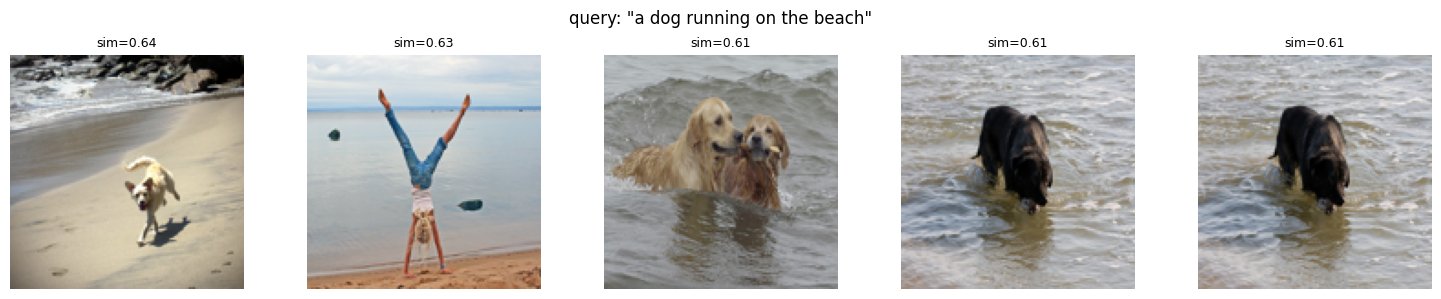

In [ ]:
def show_text_to_image_retrieval(model, index_pairs, split, img_col, query, k=5):
    tok = tokenizer(query, padding="max_length", truncation=True,
                     max_length=CFG["max_text_len"], return_tensors="np")
    input_ids = tf.constant(tok["input_ids"])
    txt_e = model.encode_text(input_ids, training=False)  # (1, D)

    raw_imgs, processed_imgs = [], []
    for row_idx, _ in index_pairs:
        pil_img = split[int(row_idx)][img_col]  # decoded here, held only for this call
        raw_imgs.append(pil_img)
        processed_imgs.append(preprocess_image(pil_img, CFG["img_size"], augment=False))
    imgs_tensor = tf.constant(np.stack(processed_imgs))

    img_e = model.encode_image(imgs_tensor, training=False)  # (N, D)
    sim = tf.squeeze(tf.matmul(txt_e, img_e, transpose_b=True), axis=0).numpy()  # (N,)
    top_idx = np.argsort(-sim)[:k]

    fig, axes = plt.subplots(1, k, figsize=(3 * k, 3))
    if k == 1:
        axes = [axes]
    for ax, idx in zip(axes, top_idx):
        ax.imshow(raw_imgs[idx].convert("RGB").resize((CFG["img_size"], CFG["img_size"])))
        ax.set_title(f"sim={sim[idx]:.2f}", fontsize=9)
        ax.axis("off")
    fig.suptitle(f'query: "{query}"')
    plt.tight_layout()
    plt.show()

# Try a few queries of your own here
show_text_to_image_retrieval(clip_model, val_index_pairs, split, img_col, "a dog running on the beach")


## 11. Train SigLIP

Same architecture, same data, only the loss function changes.

In [ ]:
siglip_model, siglip_history = train_model("siglip", CFG, tag="siglip")


[siglip] epoch 1/8 step 50/1776 loss 5.8614 lr 7.50e-05 elapsed 67s
[siglip] epoch 1/8 step 100/1776 loss 5.6978 lr 1.50e-04 elapsed 87s
[siglip] epoch 1/8 step 150/1776 loss 5.5956 lr 2.25e-04 elapsed 107s
[siglip] epoch 1/8 step 200/1776 loss 5.5920 lr 3.00e-04 elapsed 128s
== [siglip] epoch 1 done | train 7.6608 | val 5.5667 ==
[siglip] epoch 2/8 step 250/1776 loss 5.5373 lr 2.99e-04 elapsed 154s
[siglip] epoch 2/8 step 300/1776 loss 5.4566 lr 2.97e-04 elapsed 175s
[siglip] epoch 2/8 step 350/1776 loss 5.3554 lr 2.93e-04 elapsed 195s
[siglip] epoch 2/8 step 400/1776 loss 5.3563 lr 2.88e-04 elapsed 215s
== [siglip] epoch 2 done | train 5.3307 | val 5.2395 ==
[siglip] epoch 3/8 step 450/1776 loss 5.3331 lr 2.82e-04 elapsed 239s
[siglip] epoch 3/8 step 500/1776 loss 5.0802 lr 2.74e-04 elapsed 259s
[siglip] epoch 3/8 step 550/1776 loss 4.9939 lr 2.65e-04 elapsed 279s
[siglip] epoch 3/8 step 600/1776 loss 5.0044 lr 2.55e-04 elapsed 299s
[siglip] epoch 3/8 step 650/1776 loss 4.9699 lr 2.4

In [ ]:
siglip_metrics, siglip_img_e, siglip_txt_e, _ = zero_shot_retrieval_report(siglip_model, val_dataset, "siglip")


[siglip] text->image retrieval: {'R@1': 1.6666666666666667, 'R@5': 6.6000000000000005, 'R@10': 11.133333333333335}
[siglip] image->text retrieval: {'R@1': 2.0666666666666664, 'R@5': 7.666666666666666, 'R@10': 11.466666666666667}


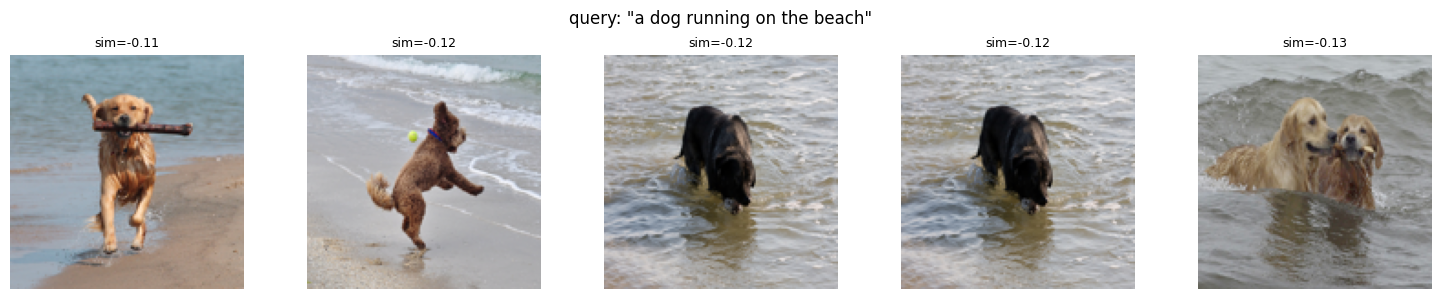

In [ ]:
show_text_to_image_retrieval(siglip_model, val_index_pairs, split, img_col, "a dog running on the beach")


## 12. CLIP vs SigLIP comparison

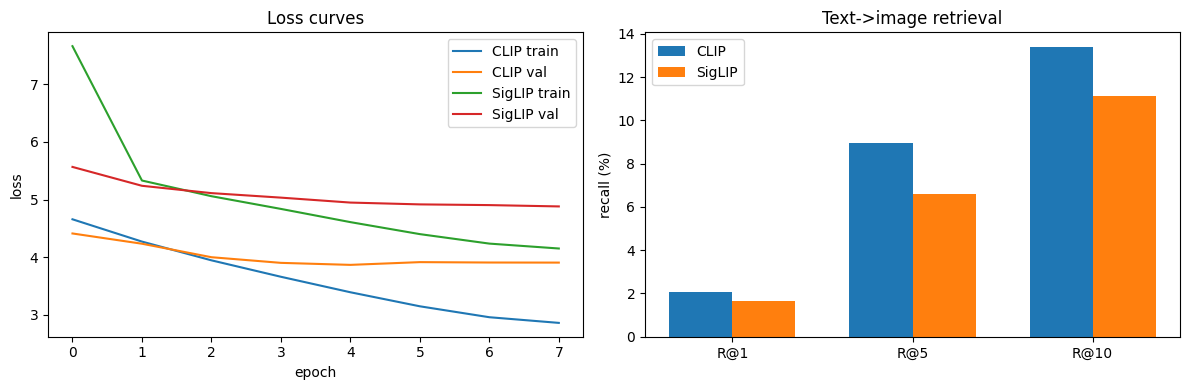


Summary table (text -> image retrieval):
metric        CLIP    SigLIP
R@1           2.07      1.67
R@5           8.93      6.60
R@10         13.40     11.13


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(clip_history["train_loss"], label="CLIP train")
axes[0].plot(clip_history["val_loss"], label="CLIP val")
axes[0].plot(siglip_history["train_loss"], label="SigLIP train")
axes[0].plot(siglip_history["val_loss"], label="SigLIP val")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].set_title("Loss curves")
axes[0].legend()

labels = ["R@1", "R@5", "R@10"]
x = np.arange(len(labels))
width = 0.35
clip_vals = [clip_metrics["text_to_image"][l] for l in labels]
siglip_vals = [siglip_metrics["text_to_image"][l] for l in labels]
axes[1].bar(x - width/2, clip_vals, width, label="CLIP")
axes[1].bar(x + width/2, siglip_vals, width, label="SigLIP")
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_ylabel("recall (%)"); axes[1].set_title("Text->image retrieval")
axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(CFG["checkpoint_dir"], "clip_vs_siglip_comparison.png"), dpi=150)
plt.show()

print("\nSummary table (text -> image retrieval):")
print(f"{'metric':<8}{'CLIP':>10}{'SigLIP':>10}")
for l in labels:
    print(f"{l:<8}{clip_metrics['text_to_image'][l]:>10.2f}{siglip_metrics['text_to_image'][l]:>10.2f}")


## 13. Save everything + notes for the README

Checkpoints already saved per-epoch to `CFG['checkpoint_dir']` (and Drive, if enabled).
This cell dumps final metrics/history to JSON so you can pull numbers straight into your
project README without re-running training.

In [ ]:
import os
import json
import numpy as np

results = {
    "clip": {"history": clip_history, "metrics": clip_metrics},
    "siglip": {"history": siglip_history, "metrics": siglip_metrics},
    "config": CFG,
    "dataset_source": ds_name,
    "num_train_pairs": len(train_index_pairs),
    "num_val_pairs": len(val_index_pairs),
}

def json_converter(obj):
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.bool_):
        return bool(obj)
    raise TypeError(f"Object of type {type(obj).__name__} is not JSON serializable")


results_path = os.path.join(CFG["checkpoint_dir"], "results.json")

with open(results_path, "w") as f:
    json.dump(results, f, indent=2, default=json_converter)

print("Saved results to", results_path)

if CFG["save_to_drive"]:
    import shutil

    shutil.copy(results_path, CFG["drive_checkpoint_dir"])
    print("Also copied to Drive.")

Saved results to /content/checkpoints/results.json
